Anomaly Detection Techniques in Python

Introduction to Anomaly Detection

Anomaly detection is a crucial technique in data analysis, used to identify unusual patterns or observations that deviate significantly from the expected behavior. In various fields such as cybersecurity, fraud detection, and system health monitoring, anomaly detection plays a vital role in identifying potential issues or threats. This slideshow will explore different techniques for anomaly detection using Python, providing practical examples and code snippets to help you understand and implement these methods.

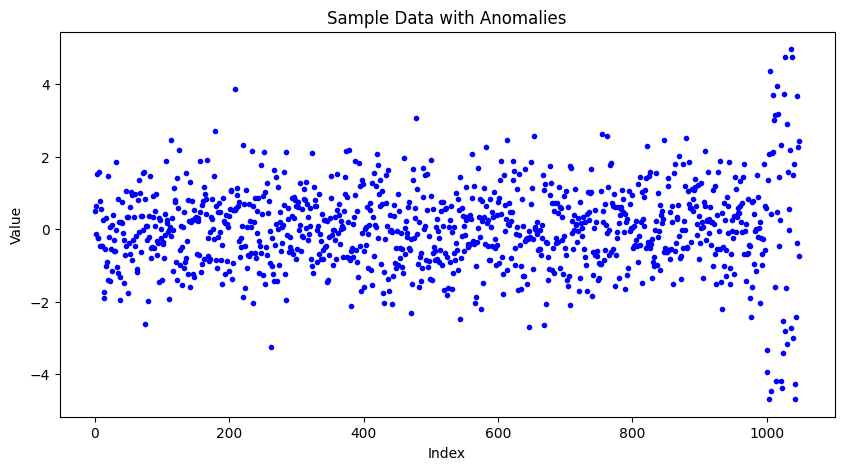

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data with anomalies
np.random.seed(42)
data = np.random.normal(0, 1, 1000)
anomalies = np.random.uniform(-5, 5, 50)
data = np.concatenate([data, anomalies])

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.title('Sample Data with Anomalies')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Statistical Approach - Z-Score Method

The Z-Score method is a simple statistical approach for detecting anomalies. It measures how many standard deviations away a data point is from the mean. Points that fall beyond a certain threshold (typically 3 standard deviations) are considered anomalies. This method works well for normally distributed data.

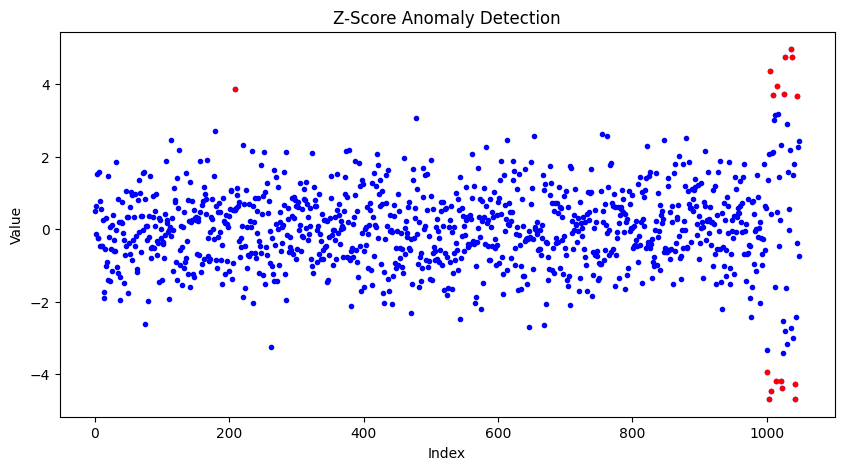

In [2]:
def z_score_anomaly_detection(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    z_scores = np.abs((data - mean) / std)
    return z_scores > threshold

anomalies = z_score_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Z-Score Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Interquartile Range (IQR) Method

The IQR method is another statistical approach that is less sensitive to extreme values compared to the Z-Score method. It uses quartiles to identify anomalies, making it suitable for data that may not be normally distributed. Points falling below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are considered anomalies.

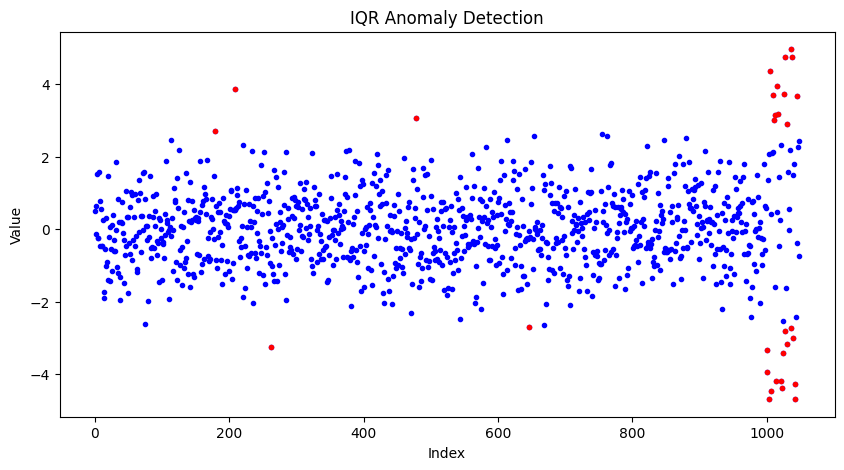

In [3]:
def iqr_anomaly_detection(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

anomalies = iqr_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('IQR Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Moving Average Method

The Moving Average method is useful for detecting anomalies in time series data. It compares each data point to the average of its neighboring points. If the difference exceeds a certain threshold, the point is considered an anomaly. This method is effective for identifying local anomalies in trends.

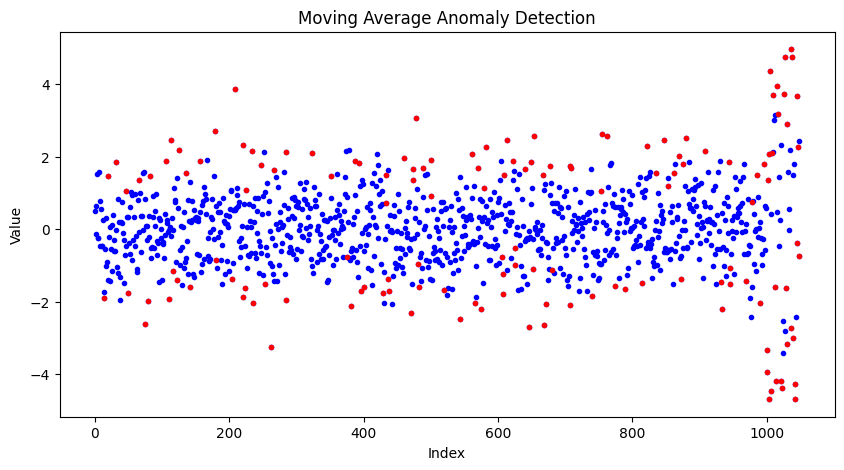

In [4]:
def moving_average_anomaly_detection(data, window=5, threshold=2):
    moving_avg = np.convolve(data, np.ones(window), 'valid') / window
    residuals = np.abs(data[window-1:] - moving_avg)
    anomalies = np.zeros(len(data), dtype=bool)
    anomalies[window-1:] = residuals > threshold * np.std(residuals)
    return anomalies

anomalies = moving_average_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Moving Average Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Isolation Forest

Isolation Forest is an unsupervised learning algorithm that isolates anomalies instead of profiling normal points. It's particularly effective for high-dimensional datasets and can handle both global and local anomalies. The algorithm builds trees by randomly selecting features and split values, isolating anomalies in fewer steps.

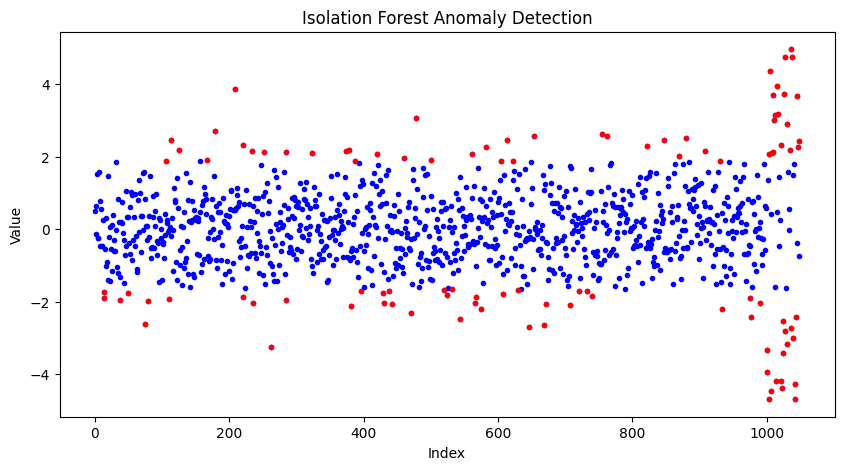

In [5]:
from sklearn.ensemble import IsolationForest

def isolation_forest_anomaly_detection(data, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    clf.fit(data.reshape(-1, 1))
    return clf.predict(data.reshape(-1, 1)) == -1

anomalies = isolation_forest_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

One-Class SVM

One-Class SVM is another unsupervised learning method for anomaly detection. It learns a decision boundary that encompasses the normal instances, treating any instances falling outside this boundary as anomalies. This method is particularly useful when you have a large amount of normal data but few or no examples of anomalies.

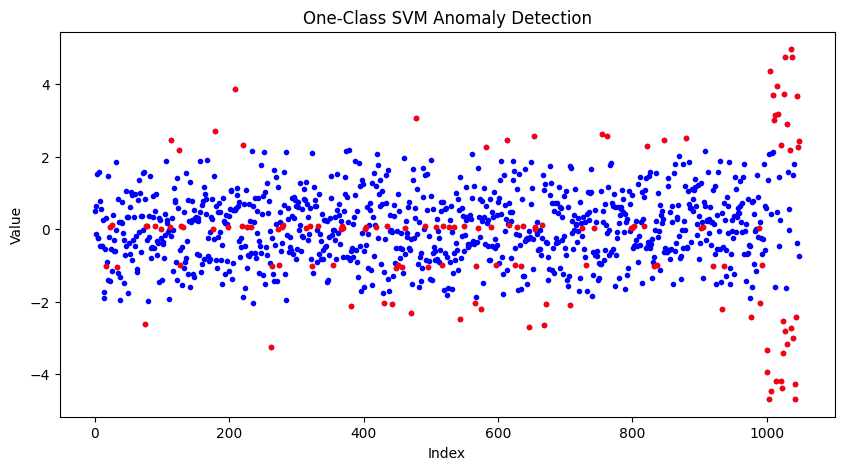

In [6]:
from sklearn.svm import OneClassSVM

def one_class_svm_anomaly_detection(data, nu=0.1):
    clf = OneClassSVM(kernel='rbf', nu=nu)
    clf.fit(data.reshape(-1, 1))
    return clf.predict(data.reshape(-1, 1)) == -1

anomalies = one_class_svm_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('One-Class SVM Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Local Outlier Factor (LOF)

Local Outlier Factor is a density-based anomaly detection method. It compares the local density of a point to the local densities of its neighbors. Points with substantially lower density than their neighbors are considered anomalies. LOF is particularly effective at detecting local anomalies in datasets with varying densities.

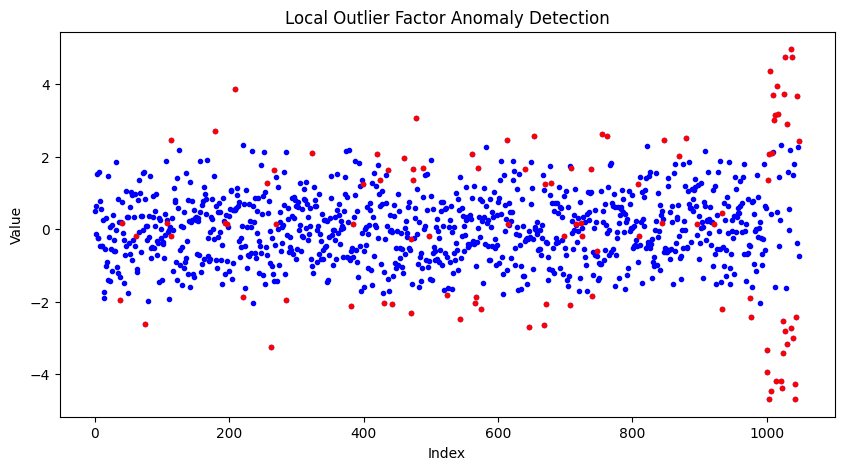

In [7]:
from sklearn.neighbors import LocalOutlierFactor

def lof_anomaly_detection(data, n_neighbors=20, contamination=0.1):
    clf = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    return clf.fit_predict(data.reshape(-1, 1)) == -1

anomalies = lof_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Local Outlier Factor Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Autoencoder for Anomaly Detection

Autoencoders are neural networks that learn to compress and reconstruct data. For anomaly detection, we train an autoencoder on normal data and use the reconstruction error to identify anomalies. High reconstruction errors indicate that the data point is likely an anomaly.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 17.7 MB/s  0:00:19m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 35.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.5 MB/s  0:00:016m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 36.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 37.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 39.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [tensorflow]5 [tensorflow]-py]a-server]


2026-02-20 19:55:01.392566: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-20 19:55:17.887083: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


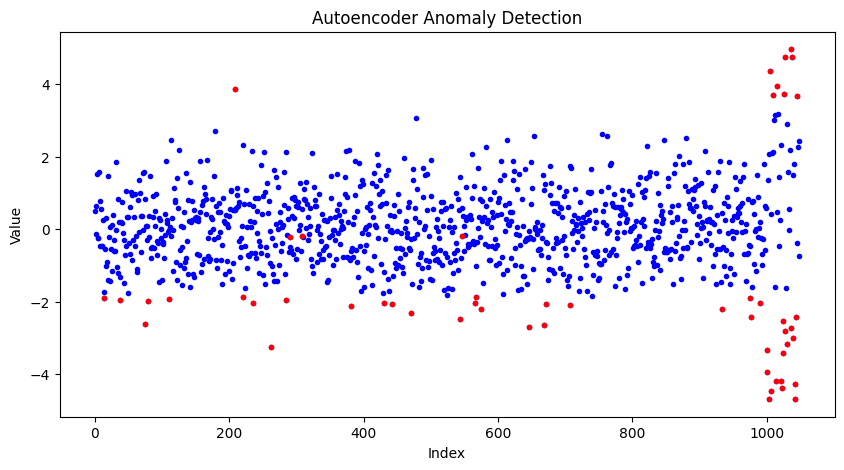

In [ ]:
# ============================================
# STEP 1: Install TensorFlow (run this cell first)
# ============================================

# !pip install tensorflow

import tensorflow as tf

def create_autoencoder(input_dim):
    encoder = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu")
    ])
    
    decoder = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(8,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(input_dim)
    ])
    
    autoencoder = tf.keras.Sequential([encoder, decoder])
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

# Assuming 'data' is your input data
autoencoder = create_autoencoder(1)
autoencoder.fit(data.reshape(-1, 1), data.reshape(-1, 1), epochs=50, batch_size=32, shuffle=True, verbose=0)

reconstructed = autoencoder.predict(data.reshape(-1, 1))
mse = np.mean(np.power(data.reshape(-1, 1) - reconstructed, 2), axis=1)
threshold = np.percentile(mse, 95)  # Adjust this threshold as needed
anomalies = mse > threshold

plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Autoencoder Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a density-based clustering algorithm that can be used for anomaly detection. It groups together points that are closely packed together, marking points that lie alone in low-density regions as outliers or anomalies. This method is particularly useful when dealing with spatial data or when the data forms clusters of varying shapes.

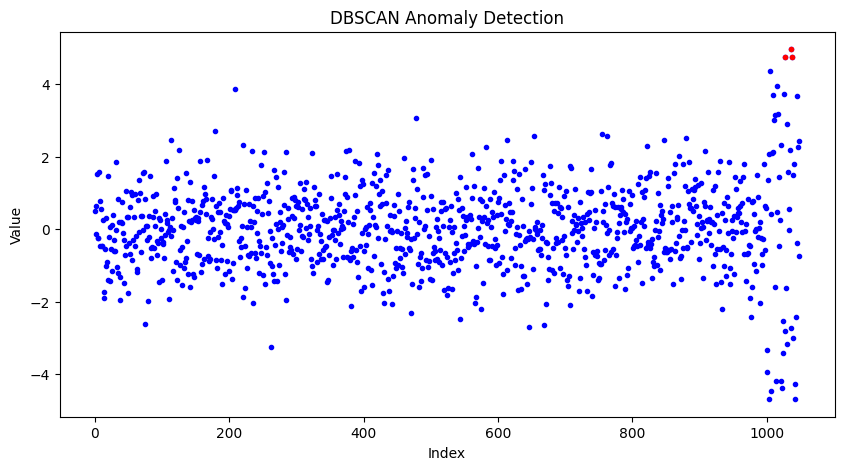

In [10]:
from sklearn.cluster import DBSCAN

def dbscan_anomaly_detection(data, eps=0.5, min_samples=5):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data.reshape(-1, 1))
    return labels == -1  # -1 indicates noise points (anomalies)

anomalies = dbscan_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('DBSCAN Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Robust Random Cut Forest

Robust Random Cut Forest is an algorithm designed for streaming anomaly detection. It builds a forest of trees, where each tree is constructed by recursively cutting the space of points. Anomalies are identified based on the average depth at which they appear in the trees. This method is particularly useful for high-dimensional data and can handle concept drift in streaming scenarios.

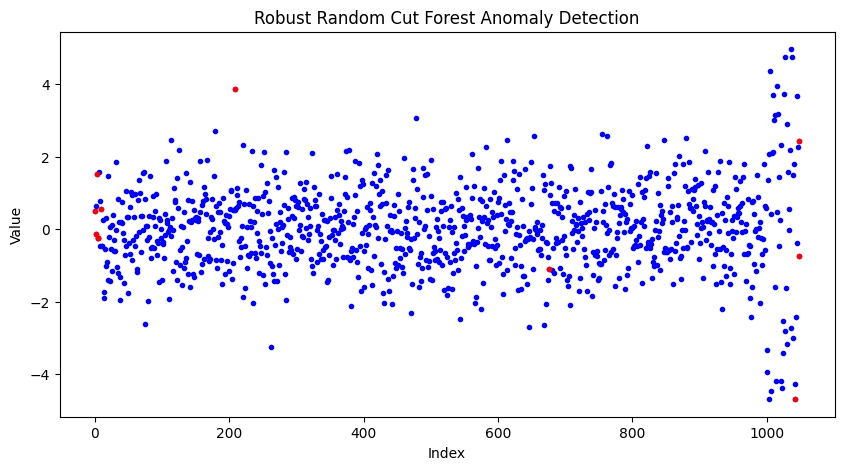

In [15]:
# ============================================
# STEP 1: Install rrcf (run this cell first)
# ============================================
#!pip install rrcf

import pandas as pd
from rrcf import RCTree

def rrcf_anomaly_detection(data, num_trees=100, tree_size=256):
    forest = []
    n_samples = len(data)
    
    for _ in range(num_trees):
        tree = RCTree()
        indices = np.random.choice(n_samples, min(n_samples, tree_size), replace=False)
        for i in indices:
            tree.insert_point((i, data[i]), index=i)
        forest.append(tree)
    
    # Use numpy array instead of pandas Series
    avg_codisp = np.zeros(n_samples)
    counts = np.zeros(n_samples)
    
    for tree in forest:
        for index in tree.leaves:
            if 0 <= index < n_samples:
                avg_codisp[index] += tree.codisp(index)
                counts[index] += 1
    
    # Average
    counts[counts == 0] = 1
    avg_codisp /= counts
    
    threshold = np.percentile(avg_codisp[avg_codisp > 0], 99)
    return avg_codisp > threshold


anomalies = rrcf_anomaly_detection(data)
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.')
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.')
plt.title('Robust Random Cut Forest Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

 Seasonal Decomposition for Time Series Anomaly Detection

When dealing with time series data that exhibits seasonality, it's often useful to decompose the series into its trend, seasonal, and residual components. Anomalies can then be detected by analyzing the residual component. This method is particularly effective for data with clear seasonal patterns, such as daily or weekly cycles.

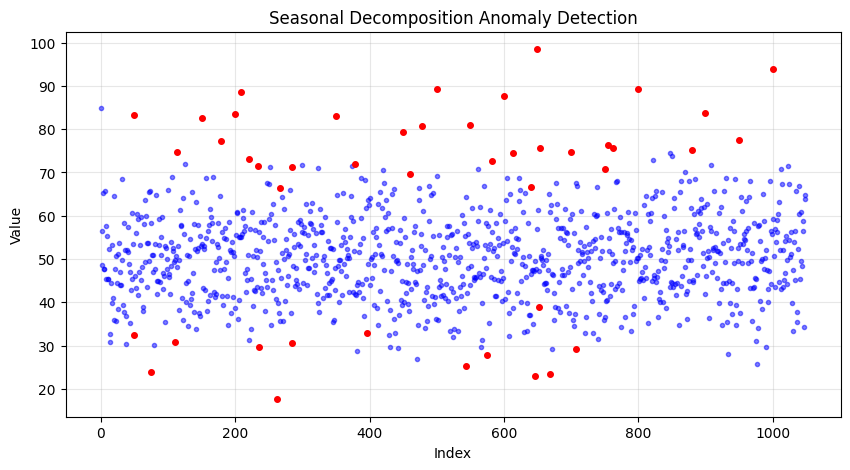

Detected 45 anomalies


In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def seasonal_decomposition_anomaly_detection(data, freq=7, threshold=2):
    # Convert to pandas Series with a datetime index
    ts = pd.Series(data, index=pd.date_range(start='2023-01-01', periods=len(data)))
    
    # Perform seasonal decomposition
    result = seasonal_decompose(ts, model='additive', period=freq)
    
    # Detect anomalies in the residual component
    residuals = result.resid
    
    # FIX: Create array aligned with original data
    mean = residuals.mean()
    std = residuals.std()
    
    # Create boolean array with same index as original data
    anomalies = pd.Series(False, index=ts.index)
    # Fill where residuals are not NaN and exceed threshold
    valid_mask = ~residuals.isna()
    anomaly_mask = (np.abs(residuals[valid_mask] - mean) > threshold * std)
    anomalies[valid_mask] = anomaly_mask
    
    return anomalies.values

# Create some sample data
np.random.seed(42)
data = np.random.randn(1050) * 10 + 50
data[::50] += 30  # Add anomalies every 50th point

# Run detection
anomalies = seasonal_decomposition_anomaly_detection(data, freq=7, threshold=2)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(data, 'b.', alpha=0.5)
plt.plot(np.where(anomalies)[0], data[anomalies], 'r.', markersize=8)
plt.title('Seasonal Decomposition Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Detected {anomalies.sum()} anomalies")

Real-Life Example: Network Traffic Anomaly Detection

Network traffic anomaly detection is crucial for identifying potential security threats or network issues. Let's simulate a scenario where we monitor the number of network requests per minute and detect unusual spikes or drops in traffic.

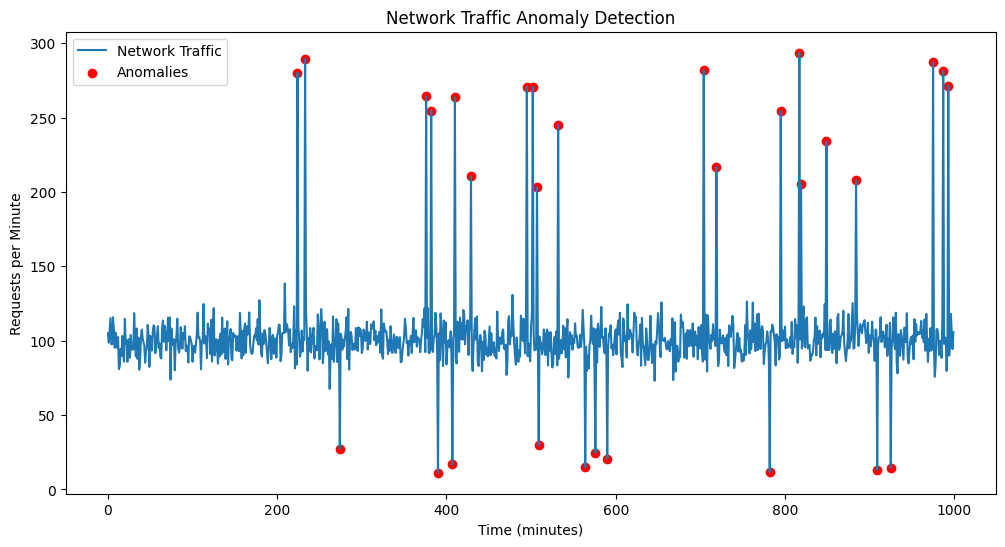

Number of detected anomalies: 30


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Simulate network traffic data (requests per minute)
np.random.seed(42)
normal_traffic = np.random.normal(100, 10, 1000)  # Normal traffic
anomalies = np.random.uniform(200, 300, 20)  # Traffic spikes
low_traffic = np.random.uniform(10, 30, 10)  # Unusually low traffic

# Combine data and introduce anomalies at random positions
data = normal_traffic.copy()
anomaly_positions = np.random.choice(len(data), len(anomalies) + len(low_traffic), replace=False)
data[anomaly_positions[:len(anomalies)]] = anomalies
data[anomaly_positions[len(anomalies):]] = low_traffic

# Detect anomalies using Isolation Forest
clf = IsolationForest(contamination=0.03, random_state=42)
anomalies = clf.fit_predict(data.reshape(-1, 1)) == -1

# Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(data, label='Network Traffic')
plt.scatter(np.where(anomalies)[0], data[anomalies], color='red', label='Anomalies')
plt.title('Network Traffic Anomaly Detection')
plt.xlabel('Time (minutes)')
plt.ylabel('Requests per Minute')
plt.legend()
plt.show()

print(f"Number of detected anomalies: {sum(anomalies)}")

Real-Life Example: Temperature Sensor Anomaly Detection

In industrial settings, monitoring equipment temperatures is crucial for preventing failures and ensuring optimal operation. Let's simulate temperature readings from a machine and detect anomalies that could indicate potential issues.

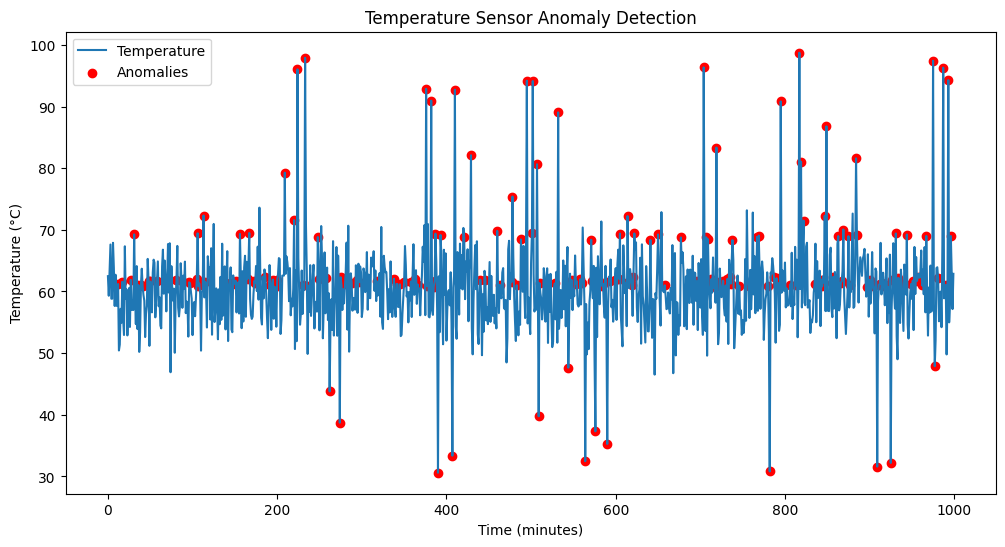

Number of detected anomalies: 201


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

# Simulate temperature sensor data
np.random.seed(42)
normal_temp = np.random.normal(60, 5, 1000)  # Normal operating temperature
anomalies = np.random.uniform(80, 100, 20)  # High temperature spikes
low_temp = np.random.uniform(30, 40, 10)  # Unusually low temperatures

# Combine data and introduce anomalies at random positions
data = normal_temp.copy()
anomaly_positions = np.random.choice(len(data), len(anomalies) + len(low_temp), replace=False)
data[anomaly_positions[:len(anomalies)]] = anomalies
data[anomaly_positions[len(anomalies):]] = low_temp

# Detect anomalies using One-Class SVM
clf = OneClassSVM(nu=0.01, kernel="rbf", gamma=0.1)
clf.fit(normal_temp.reshape(-1, 1))
anomalies = clf.predict(data.reshape(-1, 1)) == -1

# Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(data, label='Temperature')
plt.scatter(np.where(anomalies)[0], data[anomalies], color='red', label='Anomalies')
plt.title('Temperature Sensor Anomaly Detection')
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print(f"Number of detected anomalies: {sum(anomalies)}")

Comparison of Anomaly Detection Methods

Different anomaly detection methods have varying strengths and weaknesses. Here's a function to compare multiple methods on the same dataset:

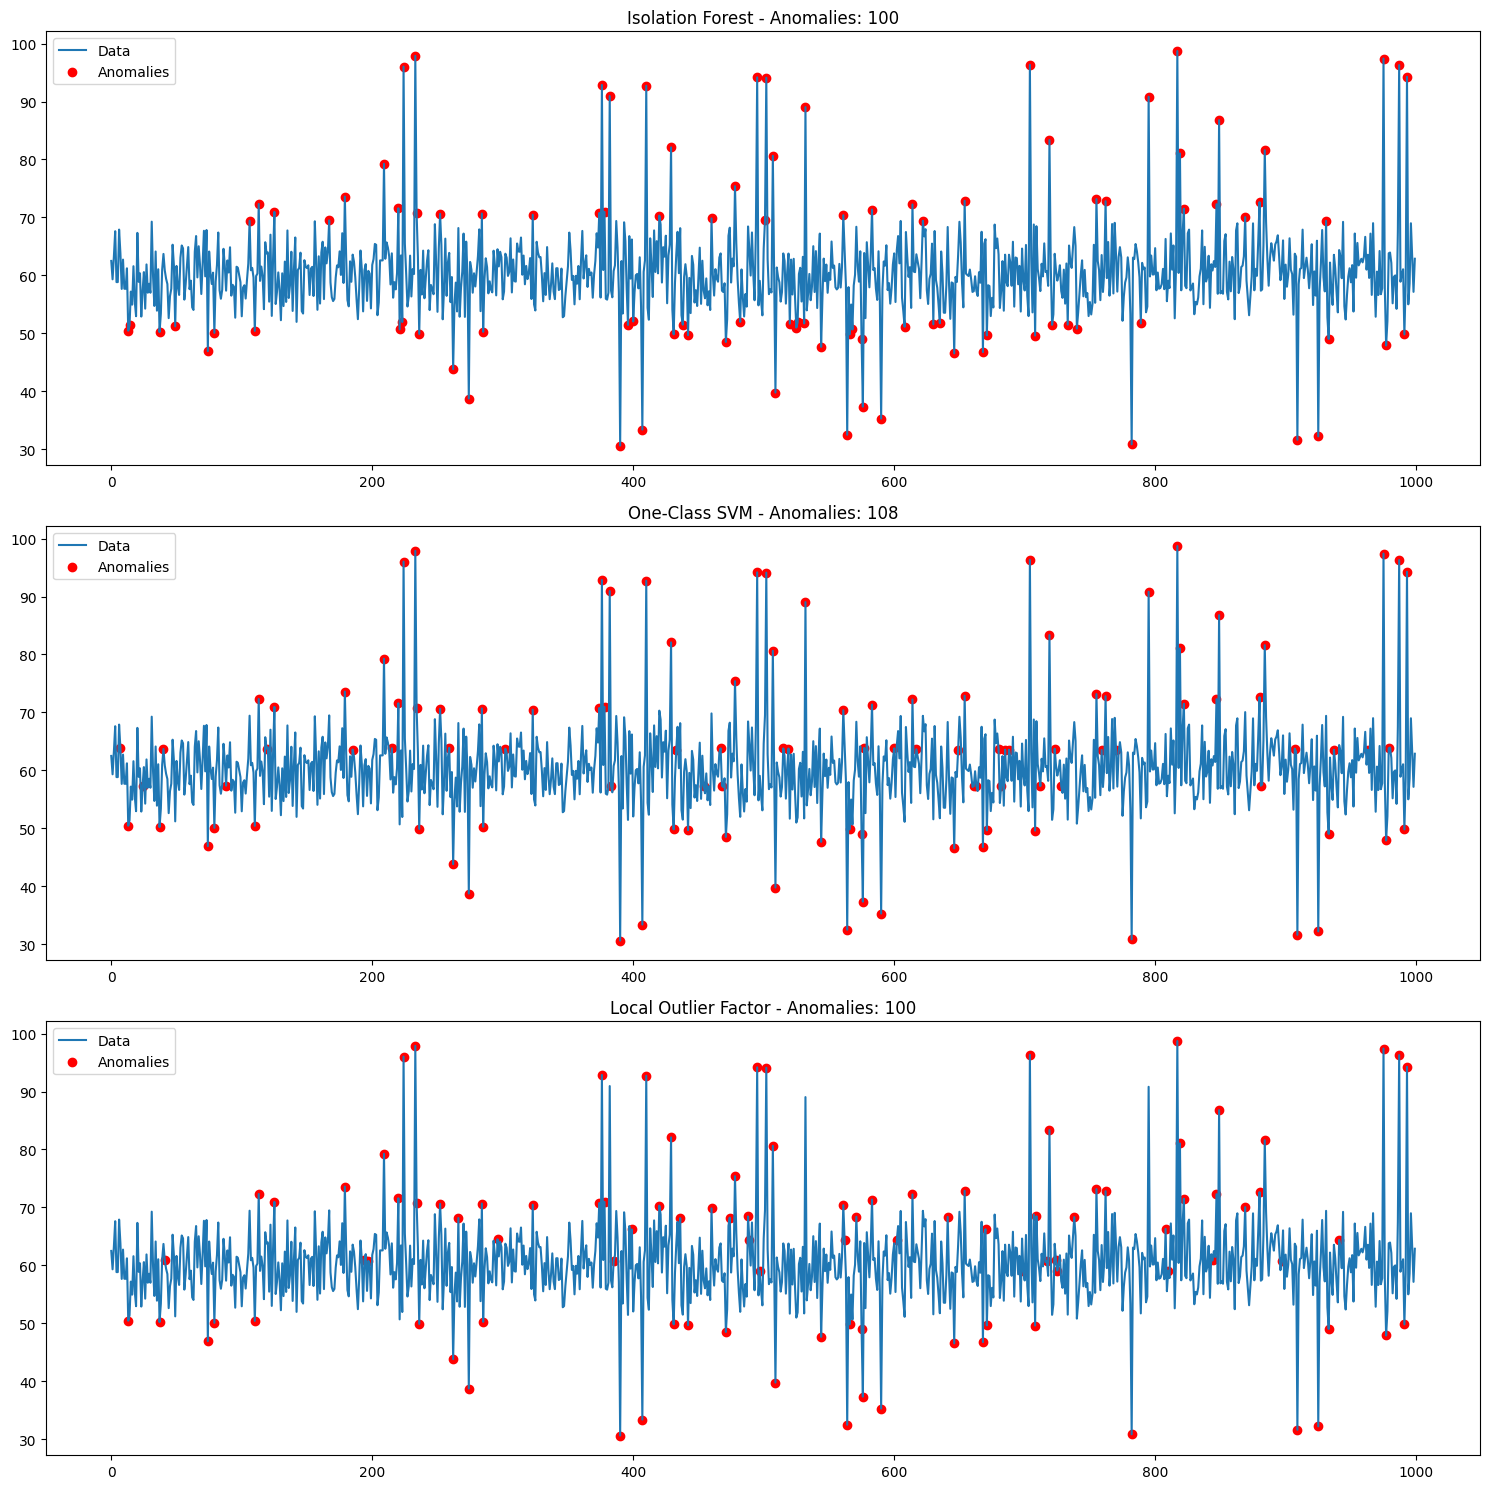

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

def compare_anomaly_detection_methods(data):
    methods = {
        'Isolation Forest': IsolationForest(contamination=0.1, random_state=42),
        'One-Class SVM': OneClassSVM(nu=0.1, kernel="rbf"),
        'Local Outlier Factor': LocalOutlierFactor(n_neighbors=20, contamination=0.1)
    }
    
    plt.figure(figsize=(15, 5 * len(methods)))
    for i, (name, method) in enumerate(methods.items()):
        if name == 'Local Outlier Factor':
            anomalies = method.fit_predict(data.reshape(-1, 1)) == -1
        else:
            method.fit(data.reshape(-1, 1))
            anomalies = method.predict(data.reshape(-1, 1)) == -1
        
        plt.subplot(len(methods), 1, i+1)
        plt.plot(data, label='Data')
        plt.scatter(np.where(anomalies)[0], data[anomalies], color='red', label='Anomalies')
        plt.title(f'{name} - Anomalies: {sum(anomalies)}')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Use the function with your data
compare_anomaly_detection_methods(data)

Additional Resources

For those interested in diving deeper into anomaly detection techniques, here are some valuable resources:

"Anomaly Detection: A Survey" by Chandola et al. (2009) - A comprehensive overview of anomaly detection techniques. ArXiv: https://arxiv.org/abs/0907.5118
"Isolation Forest" by Liu et al. (2008) - The original paper introducing the Isolation Forest algorithm. ArXiv: https://arxiv.org/abs/1811.02141
"A Comparative Evaluation of Unsupervised Anomaly Detection Algorithms for Multivariate Data" by Goldstein and Uchida (2016) - An empirical comparison of various anomaly detection methods. ArXiv: https://arxiv.org/abs/1603.04240
"Deep Learning for Anomaly Detection: A Survey" by Chalapathy and Chawla (2019) - An overview of deep learning approaches to anomaly detection. ArXiv: https://arxiv.org/abs/1901.03407
These resources provide in-depth explanations and analyses of various anomaly detection techniques, helping you further expand your knowledge in this field.